<a href="https://colab.research.google.com/github/evertonenrico/DadosDengueSorocaba/blob/main/DadosAcidentes_2022_2025_Sorocaba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de acidentes de trânsito na cidade de Sorocaba/SP (2022 - 2025)





Fonte: https://infosiga.detran.sp.gov.br/

DEPARTAMENTO ESTADUAL DE TRÂNSITO DE SÃO PAULO (Detran-SP). Infosiga: Dados abertos. São Paulo, 2025. Disponível em: https://infosiga.detran.sp.gov.br/#referencia. Acesso em: 02 mar. 2026.

In [ ]:
# Importação Pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
caminho = "/content/drive/MyDrive/Power BI Microsoft/ESTUDOS - PORTFOLIO/Acidentes Sorocaba/dataset/sinistros_2022-2026.csv" #Caminho do meu Google Drive.

In [ ]:
df = pd.read_csv(caminho, encoding="latin-1",delimiter=";") #Lendo o arquivo e passando os parâmetros de enconding e delimitador.

In [ ]:
df.head() #Leitura resumida do dados após coleta

,id_sinistro,tipo_registro,data_sinistro,ano_sinistro,mes_sinistro,dia_sinistro,hora_sinistro,ano_mes_sinistro,dia_da_semana,turno,...,tp_sinistro_colisao_traseira,tp_sinistro_colisao_lateral,tp_sinistro_colisao_transversal,tp_sinistro_colisao_outros,tp_sinistro_choque,tp_sinistro_capotamento,tp_sinistro_engavetamento,tp_sinistro_tombamento,tp_sinistro_outros,tp_sinistro_nao_disponivel
0,1554548,SINISTRO NAO FATAL,01/01/2022,2022,1,1,10:03,2022/01,Sábado,MANHA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN
1,1552983,SINISTRO NAO FATAL,01/01/2022,2022,1,1,10:13,2022/01,Sábado,MANHA,...,NaN,NaN,S,NaN,NaN,NaN,NaN,S,NaN,NaN
2,1560634,SINISTRO NAO FATAL,01/01/2022,2022,1,1,10:21,2022/01,Sábado,MANHA,...,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN
3,2464210,SINISTRO FATAL,01/01/2022,2022,1,1,05:00,2022/01,Sábado,MADRUGADA,...,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN
4,1583405,SINISTRO NAO FATAL,01/01/2022,2022,1,1,08:25,2022/01,Sábado,MANHA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN


In [ ]:
df.shape #Validar linhas x colunas

(802124, 48)

In [ ]:
df.info() #Descrição das colunas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 802124 entries, 0 to 802123
Data columns (total 48 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   id_sinistro                      802124 non-null  int64  
 1   tipo_registro                    802124 non-null  object 
 2   data_sinistro                    802124 non-null  object 
 3   ano_sinistro                     802124 non-null  int64  
 4   mes_sinistro                     802124 non-null  int64  
 5   dia_sinistro                     802124 non-null  int64  
 6   hora_sinistro                    801251 non-null  object 
 7   ano_mes_sinistro                 802124 non-null  object 
 8   dia_da_semana                    802124 non-null  object 
 9   turno                            802124 non-null  object 
 10  logradouro                       800331 non-null  object 
 11  numero_logradouro                798928 non-null  float64
 12  ti

In [ ]:
df.iloc[:10,36:48] # Validando colunas 'tp' -> "p_sinistro_colisao_traseira" float64 ?

,tp_sinistro_atropelamento,tp_sinistro_colisao_frontal,tp_sinistro_colisao_traseira,tp_sinistro_colisao_lateral,tp_sinistro_colisao_transversal,tp_sinistro_colisao_outros,tp_sinistro_choque,tp_sinistro_capotamento,tp_sinistro_engavetamento,tp_sinistro_tombamento,tp_sinistro_outros,tp_sinistro_nao_disponivel
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN
1,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,S,NaN,NaN
2,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN
3,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN
6,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,S,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN


In [ ]:
df['tp_sinistro_colisao_traseira'].describe()

,tp_sinistro_colisao_traseira
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


In [ ]:
df['tp_sinistro_colisao_traseira'] = df['tp_sinistro_colisao_traseira'].astype(object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 802124 entries, 0 to 802123
Data columns (total 48 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   id_sinistro                      802124 non-null  int64  
 1   tipo_registro                    802124 non-null  object 
 2   data_sinistro                    802124 non-null  object 
 3   ano_sinistro                     802124 non-null  int64  
 4   mes_sinistro                     802124 non-null  int64  
 5   dia_sinistro                     802124 non-null  int64  
 6   hora_sinistro                    801251 non-null  object 
 7   ano_mes_sinistro                 802124 non-null  object 
 8   dia_da_semana                    802124 non-null  object 
 9   turno                            802124 non-null  object 
 10  logradouro                       800331 non-null  object 
 11  numero_logradouro                798928 non-null  float64
 12  ti

In [ ]:
df.iloc[:,0:10].head(10) #Listando as 10 primeiras colunas

,id_sinistro,tipo_registro,data_sinistro,ano_sinistro,mes_sinistro,dia_sinistro,hora_sinistro,ano_mes_sinistro,dia_da_semana,turno
0,1554548,SINISTRO NAO FATAL,01/01/2022,2022,1,1,10:03,2022/01,Sábado,MANHA
1,1552983,SINISTRO NAO FATAL,01/01/2022,2022,1,1,10:13,2022/01,Sábado,MANHA
2,1560634,SINISTRO NAO FATAL,01/01/2022,2022,1,1,10:21,2022/01,Sábado,MANHA
3,2464210,SINISTRO FATAL,01/01/2022,2022,1,1,05:00,2022/01,Sábado,MADRUGADA
4,1583405,SINISTRO NAO FATAL,01/01/2022,2022,1,1,08:25,2022/01,Sábado,MANHA
5,1655319,NOTIFICACAO,01/01/2022,2022,1,1,13:22,2022/01,Sábado,TARDE
6,1597403,SINISTRO NAO FATAL,01/01/2022,2022,1,1,10:46,2022/01,Sábado,MANHA
7,1575925,SINISTRO NAO FATAL,01/01/2022,2022,1,1,10:48,2022/01,Sábado,MANHA
8,1556174,SINISTRO NAO FATAL,01/01/2022,2022,1,1,10:10,2022/01,Sábado,MANHA
9,1406875,NOTIFICACAO,01/01/2022,2022,1,1,07:00,2022/01,Sábado,MANHA


In [ ]:
df.iloc[:,0:10].info() #Tipo das 10 primeiras colunas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 802124 entries, 0 to 802123
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id_sinistro       802124 non-null  int64 
 1   tipo_registro     802124 non-null  object
 2   data_sinistro     802124 non-null  object
 3   ano_sinistro      802124 non-null  int64 
 4   mes_sinistro      802124 non-null  int64 
 5   dia_sinistro      802124 non-null  int64 
 6   hora_sinistro     801251 non-null  object
 7   ano_mes_sinistro  802124 non-null  object
 8   dia_da_semana     802124 non-null  object
 9   turno             802124 non-null  object
dtypes: int64(4), object(6)
memory usage: 61.2+ MB


In [ ]:
df['hora_sinistro'].isnull().sum() #Validando se a diferença na coluna são valores nulos.

np.int64(873)

In [ ]:
df['tipo_registro'].value_counts()

,count
tipo_registro,
SINISTRO NAO FATAL,493983
NOTIFICACAO,285937
SINISTRO FATAL,22204


In [ ]:
df['tipo_registro'].value_counts().sum() == len(df) #Validando Total

np.True_

In [ ]:
df['dia_da_semana'].value_counts().sort_values(ascending=False)

,count
dia_da_semana,
Sábado,129485
Sexta-feira,127920
Domingo,112394
Quinta-feira,110587
Quarta-feira,109295
Segunda-feira,106717
Terça-feira,105726


In [ ]:
df['turno'].value_counts().sort_values(ascending=False)

,count
turno,
TARDE,268333
NOITE,244032
MANHA,212119
MADRUGADA,76767
NAO DISPONIVEL,873


In [ ]:
del df['id_sinistro']

In [ ]:
df.iloc[:,0:10].head(10) #Listando as 10 primeiras colunas --com a coluna 'id_sinistro' removida

,tipo_registro,data_sinistro,ano_sinistro,mes_sinistro,dia_sinistro,hora_sinistro,ano_mes_sinistro,dia_da_semana,turno,logradouro
0,SINISTRO NAO FATAL,01/01/2022,2022,1,1,10:03,2022/01,Sábado,MANHA,AVENIDA ANTÔNIO SILVIO CUNHA BUENO
1,SINISTRO NAO FATAL,01/01/2022,2022,1,1,10:13,2022/01,Sábado,MANHA,SP 055
2,SINISTRO NAO FATAL,01/01/2022,2022,1,1,10:21,2022/01,Sábado,MANHA,SP 015 - TIETE
3,SINISTRO FATAL,01/01/2022,2022,1,1,05:00,2022/01,Sábado,MADRUGADA,RUA LETICIA
4,SINISTRO NAO FATAL,01/01/2022,2022,1,1,08:25,2022/01,Sábado,MANHA,SP 147
5,NOTIFICACAO,01/01/2022,2022,1,1,13:22,2022/01,Sábado,TARDE,AVENIDA AGUIA DE HAIA
6,SINISTRO NAO FATAL,01/01/2022,2022,1,1,10:46,2022/01,Sábado,MANHA,ESTRADA DO PERNAMBUCO
7,SINISTRO NAO FATAL,01/01/2022,2022,1,1,10:48,2022/01,Sábado,MANHA,AVENIDA ENGENHEIRO CAETANO ALVARES
8,SINISTRO NAO FATAL,01/01/2022,2022,1,1,10:10,2022/01,Sábado,MANHA,SP 330
9,NOTIFICACAO,01/01/2022,2022,1,1,07:00,2022/01,Sábado,MANHA,RUA PRAIA GRANDE


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 802124 entries, 0 to 802123
Data columns (total 47 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   tipo_registro                    802124 non-null  object 
 1   data_sinistro                    802124 non-null  object 
 2   ano_sinistro                     802124 non-null  int64  
 3   mes_sinistro                     802124 non-null  int64  
 4   dia_sinistro                     802124 non-null  int64  
 5   hora_sinistro                    801251 non-null  object 
 6   ano_mes_sinistro                 802124 non-null  object 
 7   dia_da_semana                    802124 non-null  object 
 8   turno                            802124 non-null  object 
 9   logradouro                       800331 non-null  object 
 10  numero_logradouro                798928 non-null  float64
 11  tipo_via                         802124 non-null  object 
 12  ti

In [ ]:
df.iloc[:,9:19].head()

,logradouro,numero_logradouro,tipo_via,tipo_local,latitude,longitude,cod_ibge,municipio,regiao_administrativa,administracao
0,AVENIDA ANTÔNIO SILVIO CUNHA BUENO,1802.0,VIAS URBANAS,PUBLICO,"-23,72245214","-46,61608127",3513801,DIADEMA,METROPOLITANA DE SÃO PAULO,PREFEITURA
1,SP 055,317.0,ESTRADAS E RODOVIAS,PUBLICO,"-24,14813621","-46,72810286",3522109,ITANHAEM,BAIXADA SANTISTA,ARTESP
2,SP 015 - TIETE,1.0,ESTRADAS E RODOVIAS,PUBLICO,"-23,5103932","-46,6809108",3550308,SAO PAULO,METROPOLITANA DE SÃO PAULO,PREFEITURA
3,RUA LETICIA,272.0,VIAS URBANAS,PUBLICO,"-23,690986579","-46,789732607",3550308,SAO PAULO,METROPOLITANA DE SÃO PAULO,PREFEITURA
4,SP 147,129.0,ESTRADAS E RODOVIAS,PUBLICO,"-22,70283162","-47,64755522",3538709,PIRACICABA,CAMPINAS,NAO DISPONIVEL


In [ ]:
df_sorocaba = df[df['municipio'] == 'SOROCABA']

In [ ]:
df_sorocaba.iloc[:,9:19].head(10)

,logradouro,numero_logradouro,tipo_via,tipo_local,latitude,longitude,cod_ibge,municipio,regiao_administrativa,administracao
39,SP 280,68.0,ESTRADAS E RODOVIAS,PUBLICO,"-23,51227984","-47,45379493",3552205,SOROCABA,SOROCABA,CONCESSIONÁRIA
41,AVENIDA ALTINÓPOLIS,5560.0,VIAS URBANAS,PUBLICO,"-23,46576293","-47,48946184",3552205,SOROCABA,SOROCABA,PREFEITURA
116,AV GENERAL CARNEIRO,108.0,VIAS URBANAS,PUBLICO,"-23,50181906","-47,46354427",3552205,SOROCABA,SOROCABA,PREFEITURA
228,AVENIDA DOM AGUIRRE,100.0,VIAS URBANAS,PUBLICO,"-23,50267798","-47,45276572",3552205,SOROCABA,SOROCABA,PREFEITURA
308,SP 264,103.0,ESTRADAS E RODOVIAS,PUBLICO,"-23,5409443214","-47,4870634021",3552205,SOROCABA,SOROCABA,CONCESSIONÁRIA
383,RUA PEDRO PEGORETE,607.0,VIAS URBANAS,PUBLICO,"-23,47260233","-47,46474154",3552205,SOROCABA,SOROCABA,PREFEITURA
392,AVENIDA ARMANDO PANUNZIO,10.0,VIAS URBANAS,NAO DISPONIVEL,"-23,4783216","-47,44669081",3552205,SOROCABA,SOROCABA,PREFEITURA
413,AVENIDA PEREIRA DA SILVA,260.0,VIAS URBANAS,PUBLICO,"-23,48436608","-47,44094528",3552205,SOROCABA,SOROCABA,PREFEITURA
455,SP 264,108.0,ESTRADAS E RODOVIAS,PUBLICO,"-23,57104218","-47,50384706",3552205,SOROCABA,SOROCABA,DER
483,SP 270,102.0,ESTRADAS E RODOVIAS,PUBLICO,"-23,53410849","-47,48864018",3552205,SOROCABA,SOROCABA,NAO DISPONIVEL


In [ ]:
df_sorocaba = df_sorocaba.drop(['logradouro', 'numero_logradouro','cod_ibge','municipio','regiao_administrativa'], axis=1) # removendo colunas

In [ ]:
df_sorocaba.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14690 entries, 39 to 801980
Data columns (total 42 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   tipo_registro                    14690 non-null  object 
 1   data_sinistro                    14690 non-null  object 
 2   ano_sinistro                     14690 non-null  int64  
 3   mes_sinistro                     14690 non-null  int64  
 4   dia_sinistro                     14690 non-null  int64  
 5   hora_sinistro                    14678 non-null  object 
 6   ano_mes_sinistro                 14690 non-null  object 
 7   dia_da_semana                    14690 non-null  object 
 8   turno                            14690 non-null  object 
 9   tipo_via                         14690 non-null  object 
 10  tipo_local                       14652 non-null  object 
 11  latitude                         14534 non-null  object 
 12  longitude            

In [ ]:
df_sorocaba.iloc[:,14:17]

,conservacao,circunscricao,tp_sinistro_primario
39,COLINAS,ESTADUAL,CHOQUE
41,PREFEITURA,MUNICIPAL,COLISAO
116,PREFEITURA,MUNICIPAL,COLISAO
228,PREFEITURA,MUNICIPAL,COLISAO
308,ROTA SOROCABANA,ESTADUAL,COLISAO
...,...,...,...
801725,PREFEITURA,MUNICIPAL,COLISAO
801752,PREFEITURA,MUNICIPAL,COLISAO
801806,PREFEITURA,MUNICIPAL,OUTROS
801947,PREFEITURA,MUNICIPAL,COLISAO


In [ ]:
df['conservacao'].value_counts().sort_values(ascending=False)

,count
conservacao,
PREFEITURA,676798
NAO DISPONIVEL,20702
NOVADUTRA,10586
AUTOBAN,5540
AUTOPISTA REGIS BITTENCOURT,4862
...,...
DR11 - ARAÇATUBA,2
DR08 - RIBEIRÃO PRETO,2
DR04 - ARARAQUARA,1


In [ ]:
del df_sorocaba['conservacao']

In [ ]:
df_sorocaba.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14690 entries, 39 to 801980
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   tipo_registro                    14690 non-null  object 
 1   data_sinistro                    14690 non-null  object 
 2   ano_sinistro                     14690 non-null  int64  
 3   mes_sinistro                     14690 non-null  int64  
 4   dia_sinistro                     14690 non-null  int64  
 5   hora_sinistro                    14678 non-null  object 
 6   ano_mes_sinistro                 14690 non-null  object 
 7   dia_da_semana                    14690 non-null  object 
 8   turno                            14690 non-null  object 
 9   tipo_via                         14690 non-null  object 
 10  tipo_local                       14652 non-null  object 
 11  latitude                         14534 non-null  object 
 12  longitude            

In [ ]:
df_sorocaba.describe()

,ano_sinistro,mes_sinistro,dia_sinistro,qtd_pedestre,qtd_bicicleta,qtd_motocicleta,qtd_automovel,qtd_onibus,qtd_caminhao,qtd_veic_outros,qtd_veic_nao_disponivel,qtd_gravidade_fatal,qtd_gravidade_grave,qtd_gravidade_leve,qtd_gravidade_ileso,qtd_gravidade_nao_disponivel
count,14690.000000,14690.000000,14690.000000,766.000000,191.0,5985.000000,5558.000000,349.000000,404.000000,178.000000,1827.000000,421.000000,886.000000,7000.000000,0.0,1449.000000
mean,2023.516882,6.474132,15.684752,1.131854,1.0,1.067001,1.202231,1.008596,1.099010,1.016854,1.200328,1.045131,1.083521,1.201429,NaN,1.068323
std,1.133427,3.381748,8.770293,0.398826,0.0,0.257940,0.517586,0.092448,0.345261,0.129087,0.431939,0.229609,0.300319,0.502883,NaN,0.308977
min,2022.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,1.000000
25%,2023.000000,4.000000,8.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,1.000000
50%,2023.000000,6.000000,16.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,1.000000
75%,2025.000000,9.000000,23.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,1.000000
max,2026.000000,12.000000,31.000000,5.000000,1.0,4.000000,7.000000,2.000000,3.000000,2.000000,5.000000,3.000000,4.000000,9.000000,NaN,5.000000


In [ ]:
df_sorocaba["data_sinistro"] = pd.to_datetime(df_sorocaba["data_sinistro"], format="%d/%m/%Y") #Converter Data Sinistro para DATA

In [ ]:
df_sorocaba.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14690 entries, 39 to 801980
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   tipo_registro                    14690 non-null  object        
 1   data_sinistro                    14690 non-null  datetime64[ns]
 2   ano_sinistro                     14690 non-null  int64         
 3   mes_sinistro                     14690 non-null  int64         
 4   dia_sinistro                     14690 non-null  int64         
 5   hora_sinistro                    14678 non-null  object        
 6   ano_mes_sinistro                 14690 non-null  object        
 7   dia_da_semana                    14690 non-null  object        
 8   turno                            14690 non-null  object        
 9   tipo_via                         14690 non-null  object        
 10  tipo_local                       14652 non-null  object      

In [ ]:
df_sorocaba = df_sorocaba[df_sorocaba['ano_sinistro'] < 2026] # Filtrando ano complento 2022 - 2025

In [ ]:
df_sorocaba.isna().sum() #Verificar NA (nulos) no DF

,0
tipo_registro,0
data_sinistro,0
ano_sinistro,0
mes_sinistro,0
dia_sinistro,0
hora_sinistro,12
ano_mes_sinistro,0
dia_da_semana,0
turno,0
tipo_via,0


In [ ]:
df_sorocaba.head()

,tipo_registro,data_sinistro,ano_sinistro,mes_sinistro,dia_sinistro,hora_sinistro,ano_mes_sinistro,dia_da_semana,turno,tipo_via,...,tp_sinistro_colisao_traseira,tp_sinistro_colisao_lateral,tp_sinistro_colisao_transversal,tp_sinistro_colisao_outros,tp_sinistro_choque,tp_sinistro_capotamento,tp_sinistro_engavetamento,tp_sinistro_tombamento,tp_sinistro_outros,tp_sinistro_nao_disponivel
39,SINISTRO NAO FATAL,2022-01-01,2022,1,1,13:43,2022/01,Sábado,TARDE,ESTRADAS E RODOVIAS,...,NaN,NaN,NaN,NaN,S,S,NaN,NaN,NaN,NaN
41,SINISTRO NAO FATAL,2022-01-01,2022,1,1,14:20,2022/01,Sábado,TARDE,VIAS URBANAS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116,SINISTRO NAO FATAL,2022-01-01,2022,1,1,19:06,2022/01,Sábado,NOITE,VIAS URBANAS,...,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
228,SINISTRO NAO FATAL,2022-01-01,2022,1,1,02:00,2022/01,Sábado,MADRUGADA,VIAS URBANAS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN
308,SINISTRO NAO FATAL,2022-01-01,2022,1,1,11:21,2022/01,Sábado,MANHA,ESTRADAS E RODOVIAS,...,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN


In [ ]:
df_sorocaba['hora_sinistro'] =  df_sorocaba['hora_sinistro'].str[:2] #Removendo os minutos da coluna 'hora_sinistro'

df_sorocaba['hora_sinistro'] = df_sorocaba['hora_sinistro'].astype('Int64')

In [ ]:
df_sorocaba.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14510 entries, 39 to 788996
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   tipo_registro                    14510 non-null  object        
 1   data_sinistro                    14510 non-null  datetime64[ns]
 2   ano_sinistro                     14510 non-null  int64         
 3   mes_sinistro                     14510 non-null  int64         
 4   dia_sinistro                     14510 non-null  int64         
 5   hora_sinistro                    14498 non-null  Int64         
 6   ano_mes_sinistro                 14510 non-null  object        
 7   dia_da_semana                    14510 non-null  object        
 8   turno                            14510 non-null  object        
 9   tipo_via                         14510 non-null  object        
 10  tipo_local                       14472 non-null  object      

In [ ]:
df_sorocaba.head()

,tipo_registro,data_sinistro,ano_sinistro,mes_sinistro,dia_sinistro,hora_sinistro,ano_mes_sinistro,dia_da_semana,turno,tipo_via,...,tp_sinistro_colisao_traseira,tp_sinistro_colisao_lateral,tp_sinistro_colisao_transversal,tp_sinistro_colisao_outros,tp_sinistro_choque,tp_sinistro_capotamento,tp_sinistro_engavetamento,tp_sinistro_tombamento,tp_sinistro_outros,tp_sinistro_nao_disponivel
39,SINISTRO NAO FATAL,2022-01-01,2022,1,1,13,2022/01,Sábado,TARDE,ESTRADAS E RODOVIAS,...,NaN,NaN,NaN,NaN,S,S,NaN,NaN,NaN,NaN
41,SINISTRO NAO FATAL,2022-01-01,2022,1,1,14,2022/01,Sábado,TARDE,VIAS URBANAS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116,SINISTRO NAO FATAL,2022-01-01,2022,1,1,19,2022/01,Sábado,NOITE,VIAS URBANAS,...,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
228,SINISTRO NAO FATAL,2022-01-01,2022,1,1,2,2022/01,Sábado,MADRUGADA,VIAS URBANAS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN
308,SINISTRO NAO FATAL,2022-01-01,2022,1,1,11,2022/01,Sábado,MANHA,ESTRADAS E RODOVIAS,...,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN


In [ ]:
df_sorocaba.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14510 entries, 39 to 788996
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   tipo_registro                    14510 non-null  object        
 1   data_sinistro                    14510 non-null  datetime64[ns]
 2   ano_sinistro                     14510 non-null  int64         
 3   mes_sinistro                     14510 non-null  int64         
 4   dia_sinistro                     14510 non-null  int64         
 5   hora_sinistro                    14498 non-null  Int64         
 6   ano_mes_sinistro                 14510 non-null  object        
 7   dia_da_semana                    14510 non-null  object        
 8   turno                            14510 non-null  object        
 9   tipo_via                         14510 non-null  object        
 10  tipo_local                       14472 non-null  object      

In [ ]:
df_sorocaba.iloc[:,29:41].head()

,tp_sinistro_atropelamento,tp_sinistro_colisao_frontal,tp_sinistro_colisao_traseira,tp_sinistro_colisao_lateral,tp_sinistro_colisao_transversal,tp_sinistro_colisao_outros,tp_sinistro_choque,tp_sinistro_capotamento,tp_sinistro_engavetamento,tp_sinistro_tombamento,tp_sinistro_outros,tp_sinistro_nao_disponivel
39,NaN,NaN,NaN,NaN,NaN,NaN,S,S,NaN,NaN,NaN,NaN
41,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
228,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN
308,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN


In [ ]:
df_sorocaba.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14510 entries, 39 to 788996
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   tipo_registro                    14510 non-null  object        
 1   data_sinistro                    14510 non-null  datetime64[ns]
 2   ano_sinistro                     14510 non-null  int64         
 3   mes_sinistro                     14510 non-null  int64         
 4   dia_sinistro                     14510 non-null  int64         
 5   hora_sinistro                    14498 non-null  Int64         
 6   ano_mes_sinistro                 14510 non-null  object        
 7   dia_da_semana                    14510 non-null  object        
 8   turno                            14510 non-null  object        
 9   tipo_via                         14510 non-null  object        
 10  tipo_local                       14472 non-null  object      

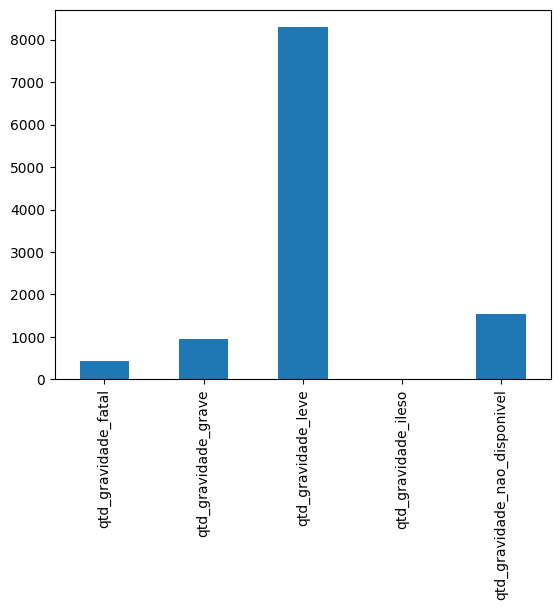

In [ ]:
df_sorocaba.iloc[:,24:29].sum().plot(kind='bar');

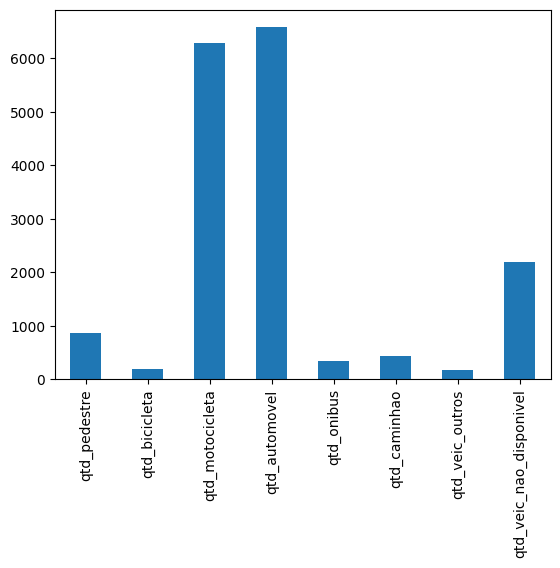

In [ ]:
df_sorocaba.iloc[:,16:24].sum().plot(kind='bar');

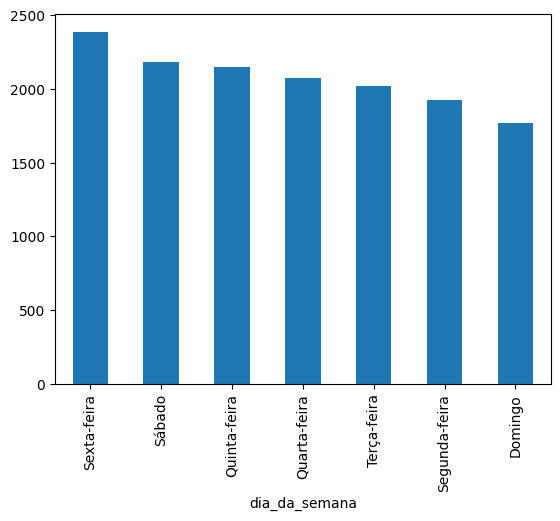

In [ ]:
df_sorocaba['dia_da_semana'].value_counts().plot(kind='bar');

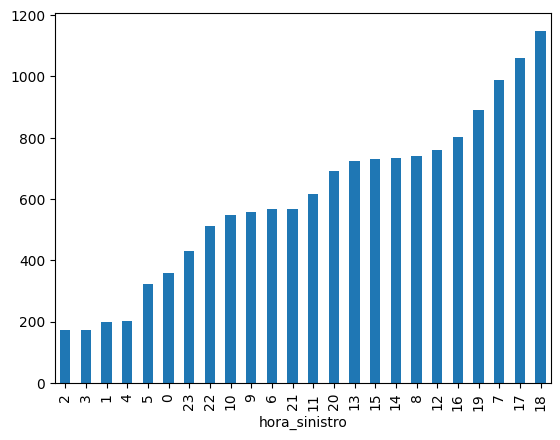

In [ ]:
df_sorocaba['hora_sinistro'].value_counts().sort_values().plot(kind='bar');

<Axes: xlabel='turno'>

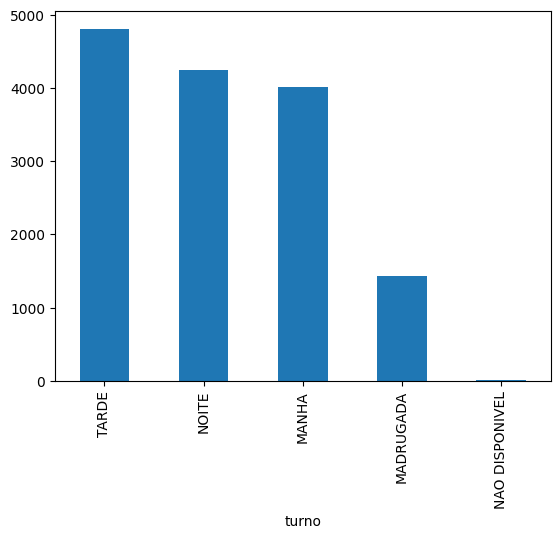

In [ ]:
df_sorocaba['turno'].value_counts().plot(kind='bar')

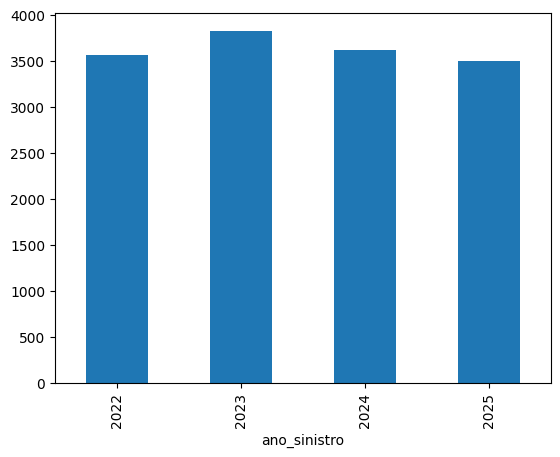

In [ ]:
df_sorocaba['ano_sinistro'].value_counts().sort_index().plot(kind='bar');

<Axes: xlabel='mes_sinistro'>

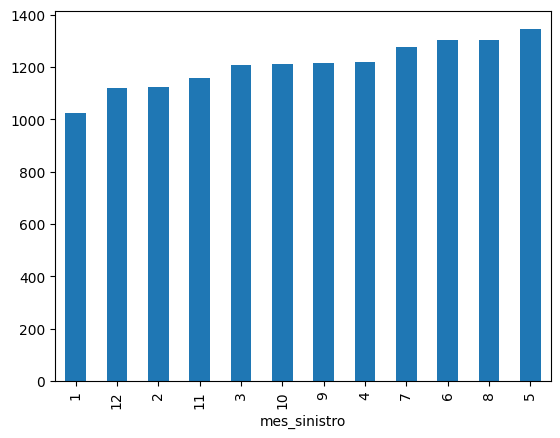

In [ ]:
df_sorocaba['mes_sinistro'].value_counts().sort_values().plot(kind = 'bar')

In [ ]:
df_sorocaba['dia_sinistro'].value_counts().sort_values(ascending=False)

,count
dia_sinistro,
21,534
23,529
24,514
28,513
11,502
4,499
22,496
9,490
5,487


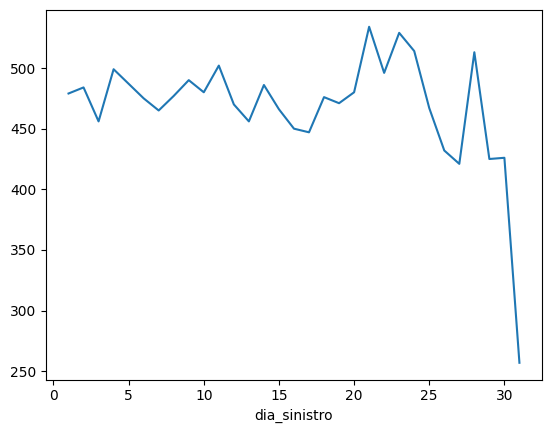

In [ ]:
df_sorocaba['dia_sinistro'].value_counts().sort_index().plot(kind='line');

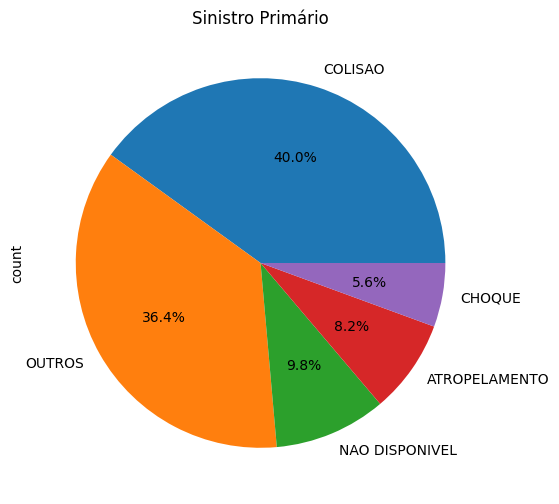

In [ ]:
# gráfico de pizza
plt.figure(figsize=(12,6))
df_sorocaba['tp_sinistro_primario'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Sinistro Primário');

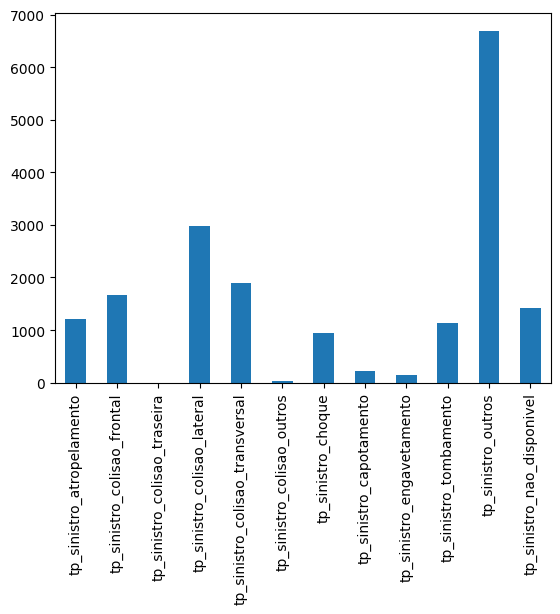

In [ ]:
df_sorocaba.iloc[:,29:41].count().plot(kind='bar');

In [ ]:
df_sorocaba.iloc[:,29:41].count().sort_values(ascending=False)

,0
tp_sinistro_outros,6693
tp_sinistro_colisao_lateral,2986
tp_sinistro_colisao_transversal,1892
tp_sinistro_colisao_frontal,1660
tp_sinistro_nao_disponivel,1422
tp_sinistro_atropelamento,1208
tp_sinistro_tombamento,1141
tp_sinistro_choque,952
tp_sinistro_capotamento,213
tp_sinistro_engavetamento,143


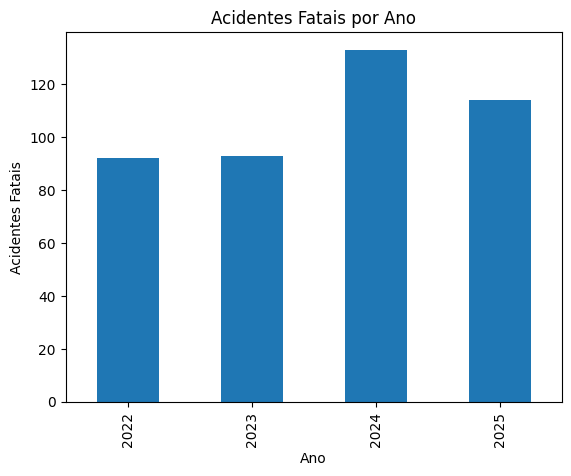

In [ ]:
df_sorocaba.groupby('ano_sinistro')['qtd_gravidade_fatal'].sum().plot(kind='bar');
plt.title('Acidentes Fatais por Ano');
plt.xlabel('Ano');
plt.ylabel('Acidentes Fatais');

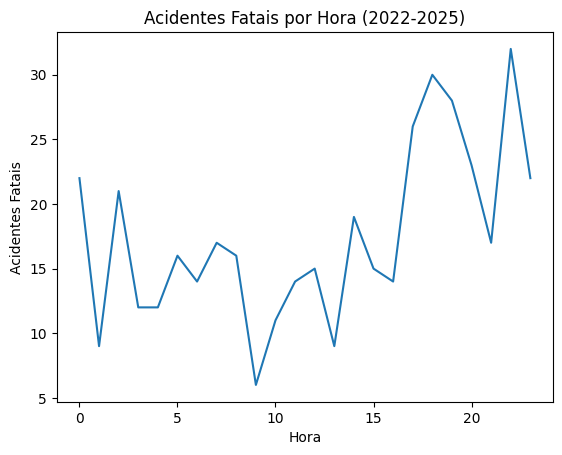

In [ ]:
df_sorocaba.groupby('hora_sinistro')['qtd_gravidade_fatal'].sum().plot(kind='line');
plt.title('Acidentes Fatais por Hora (2022-2025)');
plt.xlabel('Hora');
plt.ylabel('Acidentes Fatais');

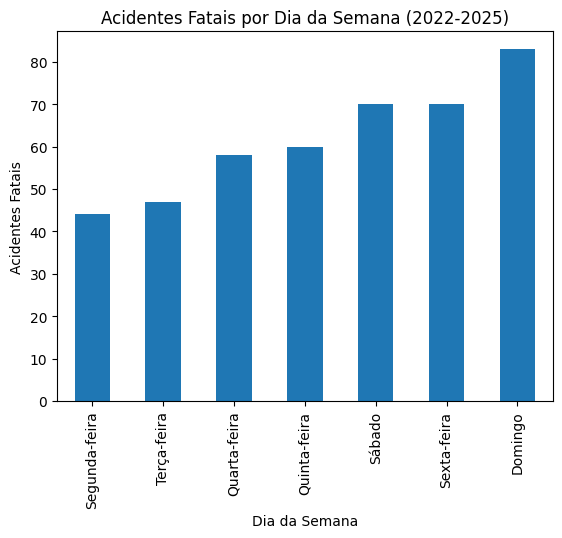

In [ ]:
df_sorocaba.groupby('dia_da_semana')['qtd_gravidade_fatal'].sum().sort_values().plot(kind='bar');
plt.title('Acidentes Fatais por Dia da Semana (2022-2025)');
plt.xlabel('Dia da Semana');
plt.ylabel('Acidentes Fatais');

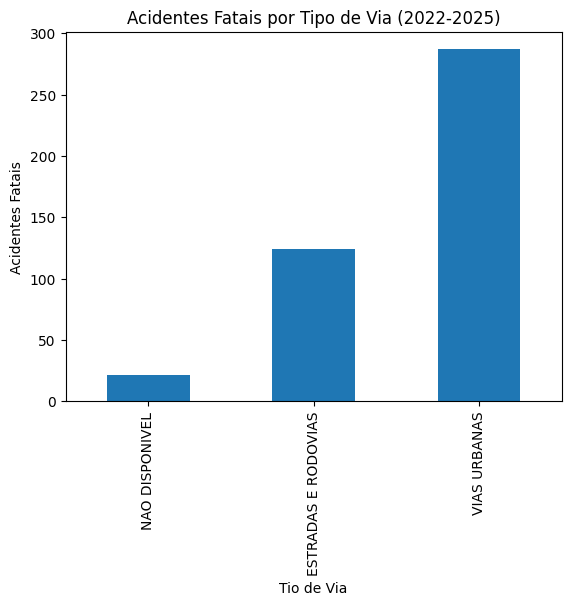

In [ ]:
df_sorocaba.groupby('tipo_via')['qtd_gravidade_fatal'].sum().sort_values().plot(kind='bar');
plt.title('Acidentes Fatais por Tipo de Via (2022-2025)');
plt.xlabel('Tio de Via');
plt.ylabel('Acidentes Fatais');

In [ ]:
df_sorocaba.groupby('tipo_via')['qtd_gravidade_fatal'].sum().sort_values(ascending=False)

,qtd_gravidade_fatal
tipo_via,
VIAS URBANAS,287.0
ESTRADAS E RODOVIAS,124.0
NAO DISPONIVEL,21.0


<Axes: ylabel='count'>

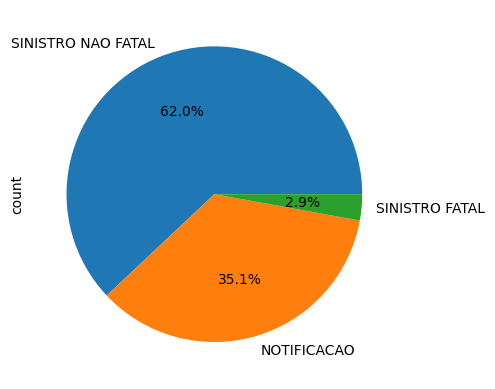

In [ ]:
df_sorocaba['tipo_registro'].value_counts().plot(kind='pie',autopct='%1.1f%%')

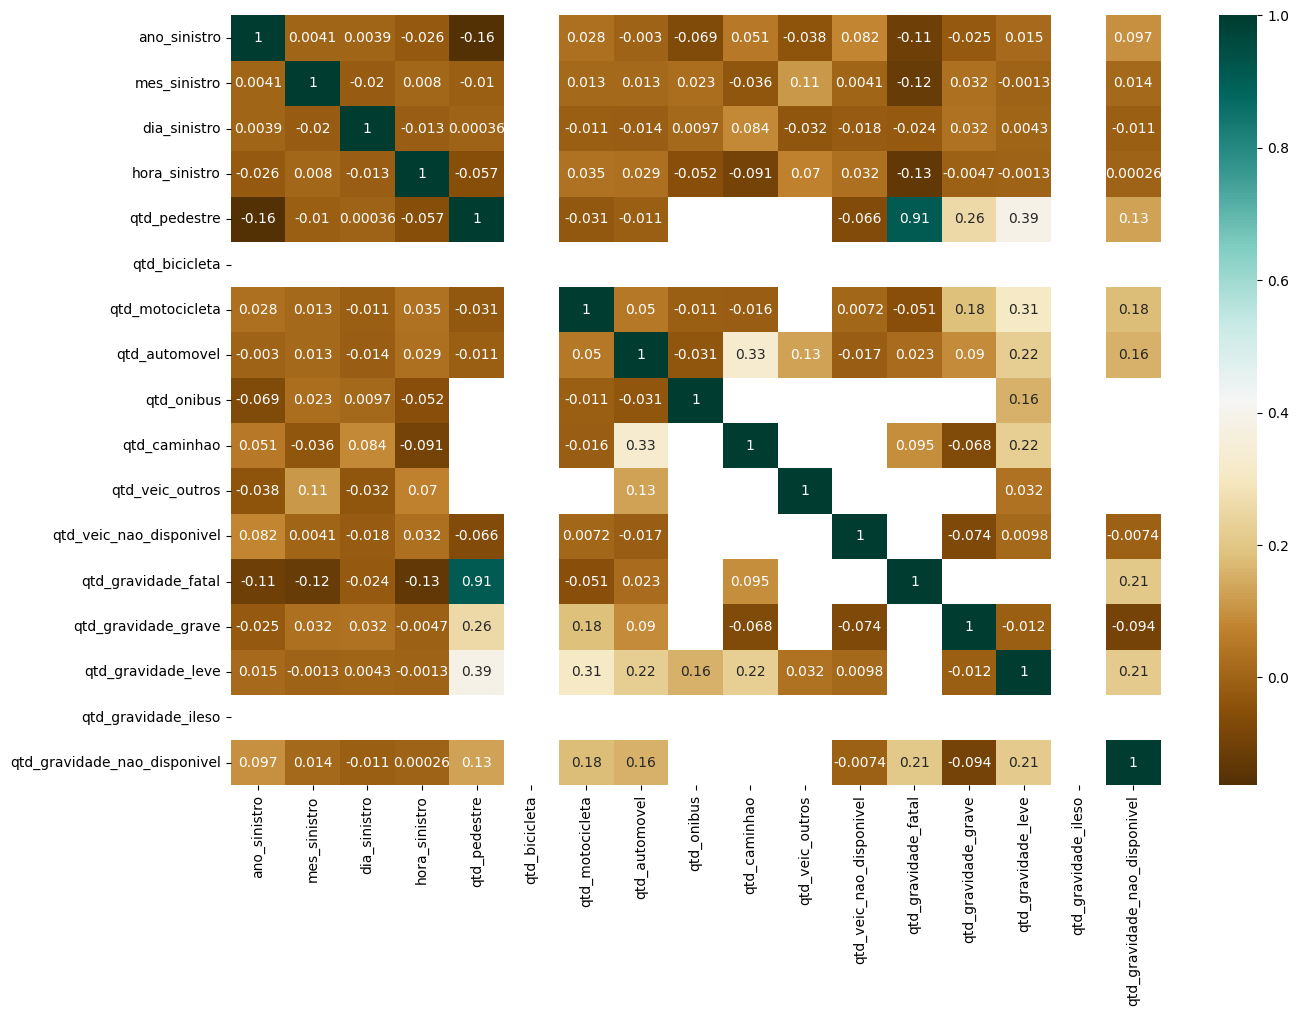

In [ ]:

# heatmap com opções
plt.figure(figsize=(15,10))
sns.heatmap(df_sorocaba.corr(numeric_only=True),cmap="BrBG",annot=True);

tipo_registro,NOTIFICACAO,SINISTRO FATAL,SINISTRO NAO FATAL
turno,,,
MADRUGADA,489,83,854
MANHA,1256,74,2686
NAO DISPONIVEL,0,12,0
NOITE,1560,148,2536
TARDE,1792,97,2923


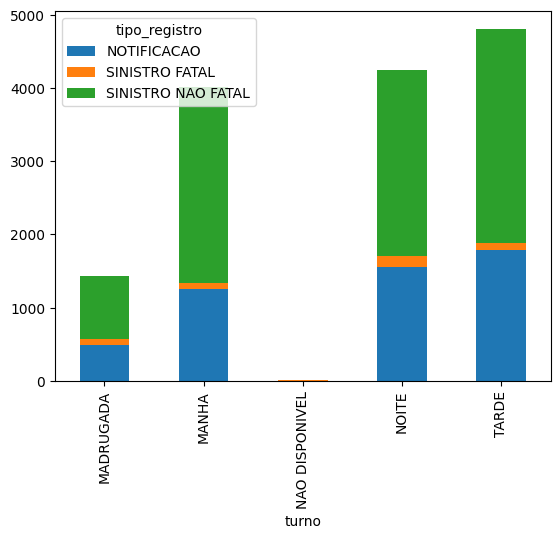

In [ ]:
tabela = pd.crosstab (df_sorocaba['turno'] ,df_sorocaba['tipo_registro'])

tabela.plot(kind='bar', stacked=True)

tabela.head()

In [ ]:
df_sorocaba.head()

,tipo_registro,data_sinistro,ano_sinistro,mes_sinistro,dia_sinistro,hora_sinistro,ano_mes_sinistro,dia_da_semana,turno,tipo_via,...,tp_sinistro_colisao_traseira,tp_sinistro_colisao_lateral,tp_sinistro_colisao_transversal,tp_sinistro_colisao_outros,tp_sinistro_choque,tp_sinistro_capotamento,tp_sinistro_engavetamento,tp_sinistro_tombamento,tp_sinistro_outros,tp_sinistro_nao_disponivel
39,SINISTRO NAO FATAL,2022-01-01,2022,1,1,13,2022/01,Sábado,TARDE,ESTRADAS E RODOVIAS,...,NaN,NaN,NaN,NaN,S,S,NaN,NaN,NaN,NaN
41,SINISTRO NAO FATAL,2022-01-01,2022,1,1,14,2022/01,Sábado,TARDE,VIAS URBANAS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116,SINISTRO NAO FATAL,2022-01-01,2022,1,1,19,2022/01,Sábado,NOITE,VIAS URBANAS,...,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
228,SINISTRO NAO FATAL,2022-01-01,2022,1,1,2,2022/01,Sábado,MADRUGADA,VIAS URBANAS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN
308,SINISTRO NAO FATAL,2022-01-01,2022,1,1,11,2022/01,Sábado,MANHA,ESTRADAS E RODOVIAS,...,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN


In [ ]:
df_sorocaba['latitude'] = (
    df_sorocaba['latitude']
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [ ]:
df_sorocaba['longitude'] = (
    df_sorocaba['longitude']
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [ ]:
df_sorocaba.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14510 entries, 39 to 788996
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   tipo_registro                    14510 non-null  object        
 1   data_sinistro                    14510 non-null  datetime64[ns]
 2   ano_sinistro                     14510 non-null  int64         
 3   mes_sinistro                     14510 non-null  int64         
 4   dia_sinistro                     14510 non-null  int64         
 5   hora_sinistro                    14498 non-null  Int64         
 6   ano_mes_sinistro                 14510 non-null  object        
 7   dia_da_semana                    14510 non-null  object        
 8   turno                            14510 non-null  object        
 9   tipo_via                         14510 non-null  object        
 10  tipo_local                       14472 non-null  object      

In [ ]:
df_sorocaba['latitude'].isna().sum()
df_sorocaba_mapa = df_sorocaba.dropna(subset=['latitude', 'longitude'])

In [ ]:
import folium
from folium.plugins import HeatMap

mapa = folium.Map(location = [-23.5062, -47.4559],zoom_start= 12)

coordenadas = list(zip(df_sorocaba_mapa.latitude, df_sorocaba_mapa.longitude))
mapa_calor = HeatMap(coordenadas,radius= 10 , blur = 8)
mapa.add_child(mapa_calor)

mapa

In [ ]:
import folium
from folium.plugins import MarkerCluster

mapa = folium.Map(location = [-23.5062, -47.4559],zoom_start= 11)

coordenadas = list(zip(df_sorocaba_mapa.latitude, df_sorocaba_mapa.longitude))
mapa_cluster = MarkerCluster(coordenadas)
mapa.add_child(mapa_cluster)

mapa

In [ ]:
import folium
from folium.plugins import HeatMap

m = folium.Map([-23.5062, -47.4559], zoom_start=12)
coordenadas = list(zip(df_sorocaba_mapa.latitude, df_sorocaba_mapa.longitude))

HeatMap(coordenadas,overlay=True,blur= 15).add_to(m)

m